In [43]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base_path = "/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets"



# Use recursive search inside all subdirectories and  **/ for a recursive search:
csv_file = glob.glob(os.path.join(base_path, "**/*data.csv"), recursive=True)

print(csv_file)

for i in csv_file:
    print(i)

['/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/price_data.csv', '/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/features_data.csv']
/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/price_data.csv
/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/features_data.csv


In [44]:
# Select the 2 specific files
selected_files = [
    "price_data.csv",
    "features_data.csv",
    ]

# Filter the files to get full paths
selected_paths = [f for f in csv_file if any(name in f for name in selected_files)]


# Read and merge the files
df_list = [pd.read_csv(file, parse_dates=["timestamp"], low_memory=False) for file in selected_paths]

# Merge DataFrames on 'timestamp
merged_df = pd.merge(df_list[0],df_list[1], on="timestamp",how='inner')



# Save to a new CSV file
#output_path = "/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/final_merged.csv"
output_path = "/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/final_merged.csv"
merged_df.to_csv(output_path, index=False)

print(f"Merged CSV saved to: {output_path}")
print(merged_df)


Merged CSV saved to: /Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/final_merged.csv
                timestamp  energy_price  net_export  total_grid_load  residual_load  hydro_pumped_storage  biomass  hydropower  wind_offshore  wind_onshore  photovoltaics  other_renewable  lignite  hard_coal  fossil_gas  other_conventional
0     2023-01-01 00:00:00         -5.17    12001.75         38346.00        6575.00              1101.000  4014.25     1275.25        3059.25      28710.50           1.25           129.50  3859.25    2067.50     1817.75             1228.75
1     2023-01-01 01:00:00         -1.07    14244.25         37777.25        4885.25              1035.125  3993.25     1226.50        3586.00      29305.00           1.00           129.00  3866.50    2052.00     1663.25             1218.25
2     2023-01-01 02:00:00         -1.47    13897.50         36939.75        3830.25              1595.875  3967.25     1222.50        3842.25      29266.00   

In [45]:
# Adjust display settings for wider output
pd.set_option('display.width', 300)  # Increase the display width
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', 10)  # Limit rows displayed for clarity

df = pd.read_csv(output_path, low_memory=False)
df.head()

,timestamp,energy_price,net_export,total_grid_load,residual_load,hydro_pumped_storage,biomass,hydropower,wind_offshore,wind_onshore,photovoltaics,other_renewable,lignite,hard_coal,fossil_gas,other_conventional
0,2023-01-01 00:00:00,-5.17,12001.75,38346.00,6575.00,1101.000,4014.25,1275.25,3059.25,28710.50,1.25,129.50,3859.25,2067.50,1817.75,1228.75
1,2023-01-01 01:00:00,-1.07,14244.25,37777.25,4885.25,1035.125,3993.25,1226.50,3586.00,29305.00,1.00,129.00,3866.50,2052.00,1663.25,1218.25
2,2023-01-01 02:00:00,-1.47,13897.50,36939.75,3830.25,1595.875,3967.25,1222.50,3842.25,29266.00,1.25,129.00,3860.25,2034.25,1666.75,1211.50
3,2023-01-01 03:00:00,-5.08,12277.25,35932.50,5459.75,1900.125,3973.00,1223.25,3463.25,27008.50,1.00,129.00,3864.75,2037.00,1659.50,1211.75
4,2023-01-01 04:00:00,-4.49,12179.00,35486.25,5583.75,1994.500,3996.50,1244.00,3462.25,26438.75,1.50,128.25,3841.00,2040.25,1644.50,1214.25


In [46]:
df.columns.to_list()

['timestamp',
 'energy_price',
 'net_export',
 'total_grid_load',
 'residual_load',
 'hydro_pumped_storage',
 'biomass',
 'hydropower',
 'wind_offshore',
 'wind_onshore',
 'photovoltaics',
 'other_renewable',
 'lignite',
 'hard_coal',
 'fossil_gas',
 'other_conventional']

In [47]:
corr_df = df[['energy_price',
 'net_export',
 'total_grid_load',
 'residual_load',
 'hydro_pumped_storage',
 'biomass',
 'hydropower',
 'wind_offshore',
 'wind_onshore',
 'photovoltaics',
 'other_renewable',
 'lignite',
 'hard_coal',
 'fossil_gas',
 'other_conventional']]


corr_matrix = corr_df.corr()
print(corr_matrix)

                      energy_price  net_export  total_grid_load  residual_load  hydro_pumped_storage   biomass  hydropower  wind_offshore  wind_onshore  photovoltaics  other_renewable   lignite  hard_coal  fossil_gas  other_conventional
energy_price              1.000000   -0.423153         0.341123       0.817476             -0.128055  0.513711    0.021928      -0.228394     -0.387822      -0.357526         0.291150  0.674905   0.563529    0.651867            0.180669
net_export               -0.423153    1.000000         0.150004      -0.610264              0.145698  0.079474   -0.502305       0.480807      0.735400       0.127398         0.250942 -0.258664   0.106880   -0.210696           -0.003161
total_grid_load           0.341123    0.150004         1.000000       0.389860              0.041303  0.417897   -0.061876       0.130272      0.156148       0.200378         0.231373  0.374024   0.512027    0.548070            0.191061
residual_load             0.817476   -0.610264      

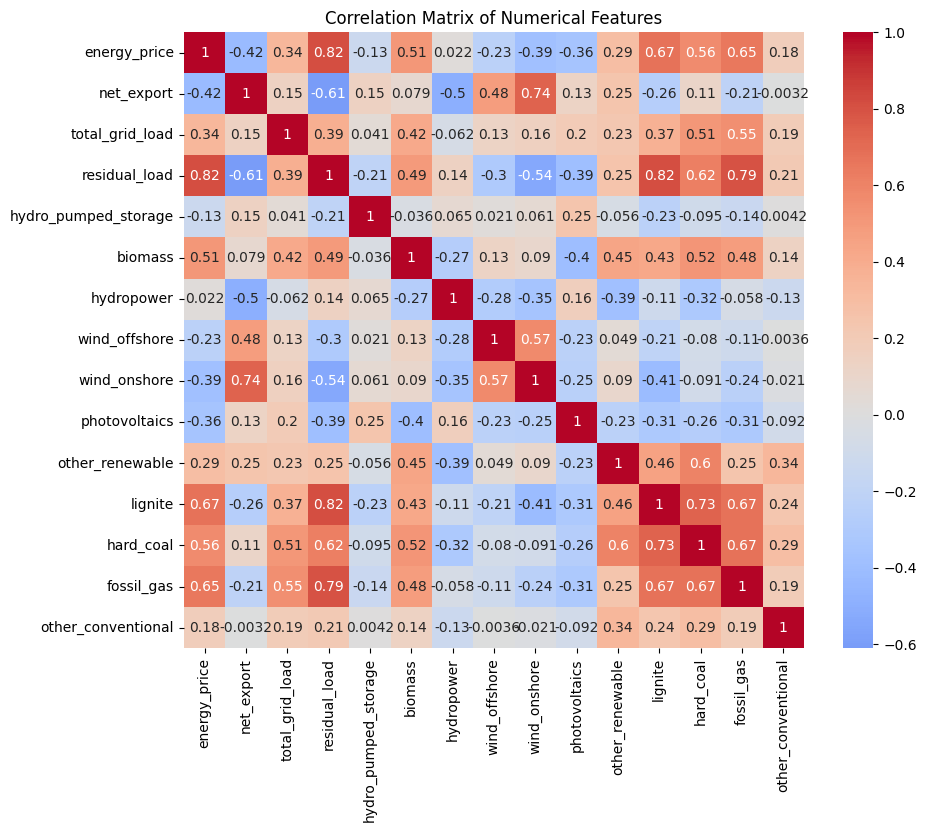

In [48]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Feature Enegineering

#### Temporal Features

In [49]:
# Now extract the hour
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['month_of_year'] = df['timestamp'].dt.month
df['season'] = df['month_of_year'] % 12//3 # 0: Winter, 1: Spring, 2: Summer, 3: Fall


#### Energy Supply & Demand Features

In [50]:
df['renewable_ratio'] = (df['wind_offshore'] + df['wind_onshore'] + df['photovoltaics'] + df['other_renewable']) / df['total_grid_load']
df['fossil_ratio'] = (df['fossil_gas'] + df['lignite'] + df['hard_coal'] + df['other_conventional']) / df['total_grid_load']
df['wind_total'] = df['wind_offshore'] + df['wind_onshore']
df['solar_wind_ratio'] = df['photovoltaics'] / (df['wind_total'] + df['photovoltaics'])
df['grid_balance'] = df['total_grid_load'] - df['net_export']
df['conventional_vs_renewable'] = (df['lignite'] + df['hard_coal'] + df['fossil_gas']) / (df['biomass'] + df['hydropower'] + df['wind_total'] + df['photovoltaics'] + df['other_renewable'])



#### Volatility & Trend Features

In [51]:
df['rolling_mean_24h'] = df['total_grid_load'].rolling(window=24, min_periods=1).mean()
df['rolling_std_24h'] = df['total_grid_load'].rolling(window=24, min_periods=1).std()
df['change_in_load_1h'] = df['total_grid_load'].diff(1)
df['change_in_wind_1h'] = df['wind_total'].diff(1)
df['change_in_fossil_1h'] = df['fossil_ratio'].diff(1)

#### Lag & Lead Features

In [52]:
df['lag_wind_1h'] = df['wind_total'].shift(1)
df['lag_wind_24h'] = df['wind_total'].shift(24)
df['lag_demand_1h'] = df['total_grid_load'].shift(1)
df['lag_demand_24h'] = df['total_grid_load'].shift(24)
df['lead_demand_1h'] = df['total_grid_load'].shift(-1)
df['lead_demand_24h'] = df['total_grid_load'].shift(-24)

#### Interaction Features

In [53]:
df['wind_solar_interaction'] = df['wind_total'] * df['photovoltaics']
df['hydro_fossil_interaction'] = df['hydropower'] * df['fossil_ratio']
df['renewable_demand_ratio'] = df['renewable_ratio'] / df['total_grid_load']


#### Seasonality 

In [54]:
# Assuming 'date' column exists in your DataFrame
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Define seasons (adjust based on your region)
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['seasonality'] = df['timestamp'].apply(get_season)

#### Tracking Periods Where Energy Price Spikes 

In [55]:
season_mapping = {
    "Winter": 1,
    "Spring": 2,
    "Summer": 3,
    "Fall": 4
}

df["seasonality"] = df["seasonality"].map(season_mapping)

In [56]:
df['spike_indicator'] = (df['energy_price'] > 400).astype(int)

In [57]:
# Calculate mean and standard deviation of energy price
mean_price = df["energy_price"].mean()
std_price = df["energy_price"].std()

# Define a spike threshold (e.g., 1 standard deviation above mean)
spike_threshold = mean_price + std_price

# Create a new column to flag price spikes (True = spike, False = no spike)
df["price_spike_tool"] = df["energy_price"] > spike_threshold

# Display rows where spikes occurred
spikes = df[df["price_spike_tool"]]
print(spikes[["timestamp", "energy_price", "price_spike_tool"]])


                timestamp  energy_price  price_spike_tool
32    2023-01-02 08:00:00        145.98              True
33    2023-01-02 09:00:00        147.05              True
34    2023-01-02 10:00:00        145.61              True
35    2023-01-02 11:00:00        143.35              True
36    2023-01-02 12:00:00        144.38              True
...                   ...           ...               ...
19039 2025-03-04 07:00:00        169.61              True
19040 2025-03-04 08:00:00        141.95              True
19049 2025-03-04 17:00:00        148.61              True
19050 2025-03-04 18:00:00        180.92              True
19051 2025-03-04 19:00:00        163.67              True

[1973 rows x 3 columns]


In [58]:
df['rolling_mean_price_24h'] = df['energy_price'].rolling(window=24).mean()
df['price_spike'] = df['energy_price'] > df['rolling_mean_price_24h']

# Show only spikes
spikes = df[df['price_spike']]
print(spikes[['energy_price', 'rolling_mean_price_24h']])


       energy_price  rolling_mean_price_24h
23            35.00               14.913333
24            57.91               17.541667
25            51.67               19.739167
26            52.93               22.005833
27            44.09               24.054583
...             ...                     ...
19050        180.92              110.625417
19051        163.67              110.114583
19052        134.13              109.432917
19053        114.38              108.856667
19054        114.41              108.418333

[9024 rows x 2 columns]


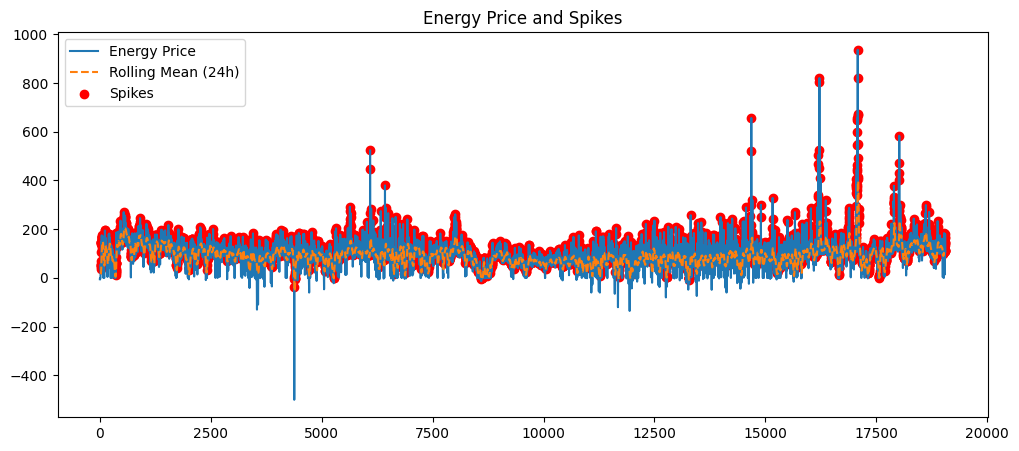

In [59]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['energy_price'], label='Energy Price')
plt.plot(df.index, df['rolling_mean_price_24h'], label='Rolling Mean (24h)', linestyle='dashed')
plt.scatter(df[df['price_spike']].index, df[df['price_spike']]['energy_price'], color='red', label='Spikes', marker='o')
plt.legend()
plt.title('Energy Price and Spikes')
plt.show()


In [60]:
df.head()

,timestamp,energy_price,net_export,total_grid_load,residual_load,hydro_pumped_storage,biomass,hydropower,wind_offshore,wind_onshore,photovoltaics,other_renewable,lignite,hard_coal,fossil_gas,other_conventional,hour_of_day,day_of_week,is_weekend,month_of_year,season,renewable_ratio,fossil_ratio,wind_total,solar_wind_ratio,grid_balance,conventional_vs_renewable,rolling_mean_24h,rolling_std_24h,change_in_load_1h,change_in_wind_1h,change_in_fossil_1h,lag_wind_1h,lag_wind_24h,lag_demand_1h,lag_demand_24h,lead_demand_1h,lead_demand_24h,wind_solar_interaction,hydro_fossil_interaction,renewable_demand_ratio,seasonality,spike_indicator,price_spike_tool,rolling_mean_price_24h,price_spike
0,2023-01-01 00:00:00,-5.17,12001.75,38346.00,6575.00,1101.000,4014.25,1275.25,3059.25,28710.50,1.25,129.50,3859.25,2067.50,1817.75,1228.75,0,6,1,1,0,0.831912,0.234007,31769.75,0.000039,26344.25,0.208241,38346.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37777.25,36789.75,39712.1875,298.418011,0.000022,1,0,False,NaN,False
1,2023-01-01 01:00:00,-1.07,14244.25,37777.25,4885.25,1035.125,3993.25,1226.50,3586.00,29305.00,1.00,129.00,3866.50,2052.00,1663.25,1218.25,1,6,1,1,0,0.874098,0.232944,32891.00,0.000030,23533.00,0.198264,38061.625000,402.166982,-568.75,1121.25,-0.001063,31769.75,NaN,38346.00,NaN,36939.75,35423.75,32891.0000,285.706344,0.000023,1,0,False,NaN,False
2,2023-01-01 02:00:00,-1.47,13897.50,36939.75,3830.25,1595.875,3967.25,1222.50,3842.25,29266.00,1.25,129.00,3860.25,2034.25,1666.75,1211.50,2,6,1,1,0,0.899803,0.237488,33108.25,0.000038,23042.25,0.196763,37687.666667,707.392144,-837.50,217.25,0.004544,32891.00,NaN,37777.25,NaN,35932.50,35284.25,41385.3125,290.329168,0.000024,1,0,False,NaN,False
3,2023-01-01 03:00:00,-5.08,12277.25,35932.50,5459.75,1900.125,3973.00,1223.25,3463.25,27008.50,1.00,129.00,3864.75,2037.00,1659.50,1211.75,3,6,1,1,0,0.851645,0.244152,30471.75,0.000033,23655.25,0.211220,37248.875000,1050.597419,-1007.25,-2636.50,0.006664,33108.25,NaN,36939.75,NaN,35486.25,36058.50,30471.7500,298.659215,0.000024,1,0,False,NaN,False
4,2023-01-01 04:00:00,-4.49,12179.00,35486.25,5583.75,1994.500,3996.50,1244.00,3462.25,26438.75,1.50,128.25,3841.00,2040.25,1644.50,1214.25,4,6,1,1,0,0.846264,0.246293,29901.00,0.000050,23307.25,0.213368,36896.350000,1203.821241,-446.25,-570.75,0.002140,30471.75,NaN,35932.50,NaN,35647.25,37796.00,44851.5000,306.387967,0.000024,1,0,False,NaN,False


In [61]:

df.fillna(df.mean(), inplace=True)
df.isna().sum()

timestamp                 0
energy_price              0
net_export                0
total_grid_load           0
residual_load             0
                         ..
seasonality               0
spike_indicator           0
price_spike_tool          0
rolling_mean_price_24h    0
price_spike               0
Length: 46, dtype: int64

In [62]:
df.describe()

,timestamp,energy_price,net_export,total_grid_load,residual_load,hydro_pumped_storage,biomass,hydropower,wind_offshore,wind_onshore,photovoltaics,other_renewable,lignite,hard_coal,fossil_gas,other_conventional,hour_of_day,day_of_week,is_weekend,month_of_year,season,renewable_ratio,fossil_ratio,wind_total,solar_wind_ratio,grid_balance,conventional_vs_renewable,rolling_mean_24h,rolling_std_24h,change_in_load_1h,change_in_wind_1h,change_in_fossil_1h,lag_wind_1h,lag_wind_24h,lag_demand_1h,lag_demand_24h,lead_demand_1h,lead_demand_24h,wind_solar_interaction,hydro_fossil_interaction,renewable_demand_ratio,seasonality,spike_indicator,rolling_mean_price_24h
count,19056,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,1.905600e+04,19056.000000,1.905600e+04,19056.000000,19056.000000,19056.000000
mean,2024-02-02 00:02:16.020151296,89.488131,-1818.428638,53095.537744,30520.445568,1313.543943,4195.979232,1802.363180,2851.400071,13193.042808,6532.011007,118.070280,8595.075317,3957.131573,6596.093409,1293.794684,11.500000,2.997481,0.285894,6.127939,1.388119,0.426553,0.381619,16044.442879,0.228852,54913.966382,0.959348,53083.992272,6893.089210,0.537090,-0.964471,0.000011,16044.582091,16049.221193,53095.774705,53090.740976,53096.311795,53110.618485,7.454405e+07,677.468137,8.253083e-06,2.388119,0.001627,89.528227
min,2023-01-01 00:00:00,-500.000000,-17359.000000,30902.750000,-8185.500000,43.625000,3214.750000,941.250000,0.250000,43.000000,0.250000,69.000000,2493.750000,309.250000,1606.250000,806.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.003095,0.116223,45.375000,0.000006,21723.250000,0.086560,36441.625000,402.166982,-16379.750000,-7066.000000,-0.121152,45.375000,45.375000,30902.750000,30902.750000,30902.750000,30902.750000,3.500000e+02,193.092116,4.690854e-08,1.000000,0.000000,-53.871250
25%,2023-07-18 12:45:00,64.717500,-7041.875000,45490.625000,20981.500000,662.500000,3977.187500,1463.750000,1140.750000,4918.125000,2.750000,97.000000,5553.062500,1873.000000,3823.937500,1192.250000,5.750000,1.000000,0.000000,3.000000,0.000000,0.226932,0.269705,6591.250000,0.000229,47217.125000,0.350955,49182.536458,5991.838367,-1532.562500,-649.062500,-0.011365,6591.250000,6591.250000,45490.625000,45490.625000,45491.000000,45525.937500,4.887005e+04,461.688855,4.333898e-06,1.000000,0.000000,66.820833
50%,2024-02-01 23:30:00,90.600000,-2401.000000,53123.750000,30596.000000,1166.312500,4210.500000,1808.250000,2669.125000,10308.625000,146.125000,109.000000,8581.625000,3121.375000,5843.875000,1315.000000,11.500000,3.000000,0.000000,6.000000,1.000000,0.407440,0.368190,13325.875000,0.011579,54609.375000,0.665040,53164.151042,7135.287804,-271.125000,-23.875000,0.000325,13325.875000,13352.875000,53123.750000,53090.740976,53123.750000,53123.750000,1.645532e+06,640.964080,7.645239e-06,2.000000,0.000000,90.234583
75%,2024-08-18 12:15:00,115.772500,2922.625000,60089.750000,39936.125000,1894.656250,4407.000000,2084.500000,4415.500000,19299.937500,10049.937500,134.000000,11247.000000,5446.812500,8471.812500,1392.250000,17.250000,5.000000,1.000000,9.000000,2.000000,0.602375,0.477459,23466.687500,0.451179,63041.000000,1.262683,57505.434896,7894.047063,1106.937500,609.312500,0.010561,23466.687500,23466.687500,60089.750000,60077.750000,60089.750000,60089.750000,9.210895e+07,846.704532,1.124744e-05,3.000000,0.000000,110.328750
max,2025-03-04 23:00:00,936.280000,18759.250000,76026.250000,69048.500000,3977.875000,5017.000000,3113.250000,7899.250000,48023.000000,46848.250000,203.750000,17173.250000,15240.500000,20146.500000,2252.500000,23.000000,6

In [63]:
# Save the updated dataset
#df.to_csv('enhanced_dataset.csv', index=False)
df.to_csv('/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/enhanced_dataset.csv', index=False)
print("Feature engineering complete. New dataset saved as 'enhanced_dataset.csv'")


Feature engineering complete. New dataset saved as 'enhanced_dataset.csv'


# Visualizations

In [64]:
df.head()

,timestamp,energy_price,net_export,total_grid_load,residual_load,hydro_pumped_storage,biomass,hydropower,wind_offshore,wind_onshore,photovoltaics,other_renewable,lignite,hard_coal,fossil_gas,other_conventional,hour_of_day,day_of_week,is_weekend,month_of_year,season,renewable_ratio,fossil_ratio,wind_total,solar_wind_ratio,grid_balance,conventional_vs_renewable,rolling_mean_24h,rolling_std_24h,change_in_load_1h,change_in_wind_1h,change_in_fossil_1h,lag_wind_1h,lag_wind_24h,lag_demand_1h,lag_demand_24h,lead_demand_1h,lead_demand_24h,wind_solar_interaction,hydro_fossil_interaction,renewable_demand_ratio,seasonality,spike_indicator,price_spike_tool,rolling_mean_price_24h,price_spike
0,2023-01-01 00:00:00,-5.17,12001.75,38346.00,6575.00,1101.000,4014.25,1275.25,3059.25,28710.50,1.25,129.50,3859.25,2067.50,1817.75,1228.75,0,6,1,1,0,0.831912,0.234007,31769.75,0.000039,26344.25,0.208241,38346.000000,6893.089210,0.53709,-0.964471,0.000011,16044.582091,16049.221193,53095.774705,53090.740976,37777.25,36789.75,39712.1875,298.418011,0.000022,1,0,False,89.528227,False
1,2023-01-01 01:00:00,-1.07,14244.25,37777.25,4885.25,1035.125,3993.25,1226.50,3586.00,29305.00,1.00,129.00,3866.50,2052.00,1663.25,1218.25,1,6,1,1,0,0.874098,0.232944,32891.00,0.000030,23533.00,0.198264,38061.625000,402.166982,-568.75000,1121.250000,-0.001063,31769.750000,16049.221193,38346.000000,53090.740976,36939.75,35423.75,32891.0000,285.706344,0.000023,1,0,False,89.528227,False
2,2023-01-01 02:00:00,-1.47,13897.50,36939.75,3830.25,1595.875,3967.25,1222.50,3842.25,29266.00,1.25,129.00,3860.25,2034.25,1666.75,1211.50,2,6,1,1,0,0.899803,0.237488,33108.25,0.000038,23042.25,0.196763,37687.666667,707.392144,-837.50000,217.250000,0.004544,32891.000000,16049.221193,37777.250000,53090.740976,35932.50,35284.25,41385.3125,290.329168,0.000024,1,0,False,89.528227,False
3,2023-01-01 03:00:00,-5.08,12277.25,35932.50,5459.75,1900.125,3973.00,1223.25,3463.25,27008.50,1.00,129.00,3864.75,2037.00,1659.50,1211.75,3,6,1,1,0,0.851645,0.244152,30471.75,0.000033,23655.25,0.211220,37248.875000,1050.597419,-1007.25000,-2636.500000,0.006664,33108.250000,16049.221193,36939.750000,53090.740976,35486.25,36058.50,30471.7500,298.659215,0.000024,1,0,False,89.528227,False
4,2023-01-01 04:00:00,-4.49,12179.00,35486.25,5583.75,1994.500,3996.50,1244.00,3462.25,26438.75,1.50,128.25,3841.00,2040.25,1644.50,1214.25,4,6,1,1,0,0.846264,0.246293,29901.00,0.000050,23307.25,0.213368,36896.350000,1203.821241,-446.25000,-570.750000,0.002140,30471.750000,16049.221193,35932.500000,53090.740976,35647.25,37796.00,44851.5000,306.387967,0.000024,1,0,False,89.528227,False


### Hourly Price Trend Plot 



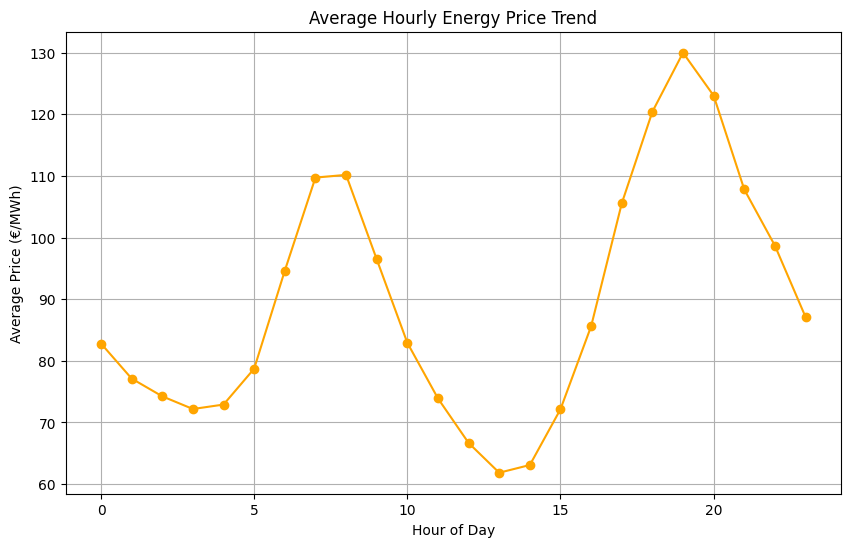

Average Price Difference (Peak - Off-Peak): 14.28 €/MWh


In [82]:
# Assuming df has 'hour_of_day' and 'energy_price'
hourly_avg_price = df.groupby('hour_of_day')['energy_price'].mean()
plt.figure(figsize=(10, 6))
plt.plot(hourly_avg_price.index, hourly_avg_price.values, marker='o', color='orange')
plt.title('Average Hourly Energy Price Trend')
plt.xlabel('Hour of Day')
plt.ylabel('Average Price (€/MWh)')
plt.grid(True)
plt.show()

# Calculate peak vs. off-peak difference
peak_hours = hourly_avg_price[8:12].mean()
off_peak_hours = hourly_avg_price[0:4].mean()
print(f"Average Price Difference (Peak - Off-Peak): {peak_hours - off_peak_hours:.2f} €/MWh")

### % of hours Where Price jumps above 400 €/MWh

In [91]:
import pandas as pd

# Assuming df is your full dataset
# Step 1: Count the number of hours where energy_price > 400 €/MWh
hours_above_400 = (df['energy_price'] > 400).sum()

# Step 2: Get the total number of hours in the dataset
total_hours = len(df)

# Step 3: Calculate the percentage
percentage_above_400 = (hours_above_400 / total_hours) * 100

# Step 4: Print the result
print(f"Percentage of hours where prices exceed 400 €/MWh: {percentage_above_400:.2f}%")

Percentage of hours where prices exceed 400 €/MWh: 0.16%


### Day-of-Week Price Trend



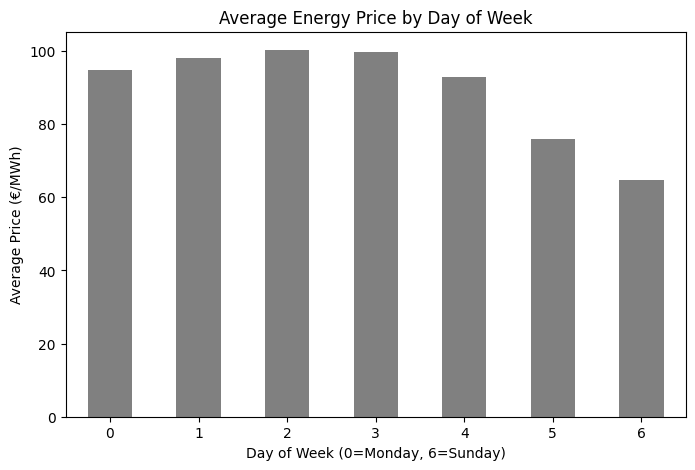

Average Price Difference (Peak - Off-Peak): nan €/MWh


'Prices spike on weekdays when demand soars—Monday to Friday \n prices average X €/MWh, while weekends drop to Y €/MWh as \n businesses slow down\n'

In [ ]:
day_of_week_avg_price = df.groupby('day_of_week')['energy_price'].mean()
plt.figure(figsize=(8, 5))
day_of_week_avg_price.plot(kind='bar', color='grey')
plt.title('Average Energy Price by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Price (€/MWh)')
plt.xticks(rotation=0)
plt.show()

"""Prices spike on weekdays when demand soars—Monday to Friday 
 prices average X €/MWh, while weekends drop to Y €/MWh as 
 businesses slow down
"""


### Seasonal Price Trend



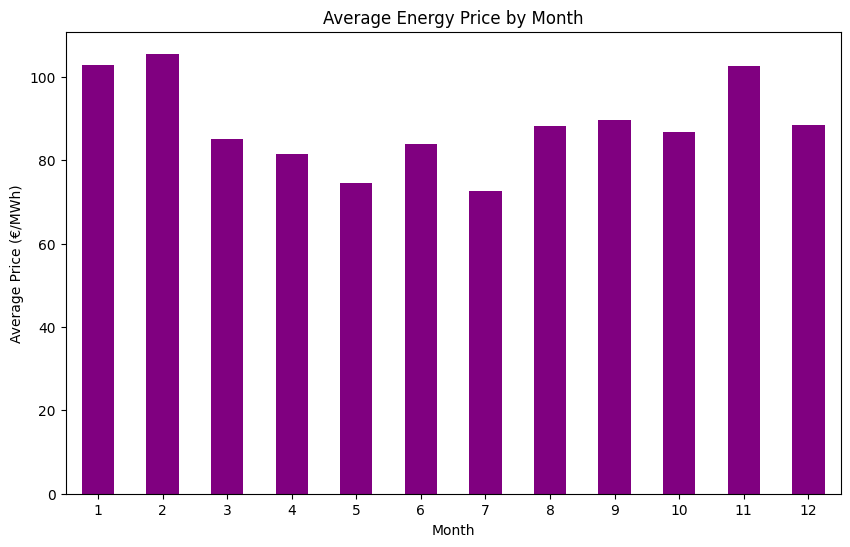

In [ ]:
monthly_avg_price = df.groupby('month_of_year')['energy_price'].mean()
plt.figure(figsize=(10, 6))
monthly_avg_price.plot(kind='bar', color='purple')
plt.title('Average Energy Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Price (€/MWh)')
plt.xticks(rotation=0)
plt.show()

"""“Winter months like January see prices jump to X €/MWh due 
to less solar power, while summer months like July drop to 
Y €/MWh with more sunshine.”"""



### Price Distribution

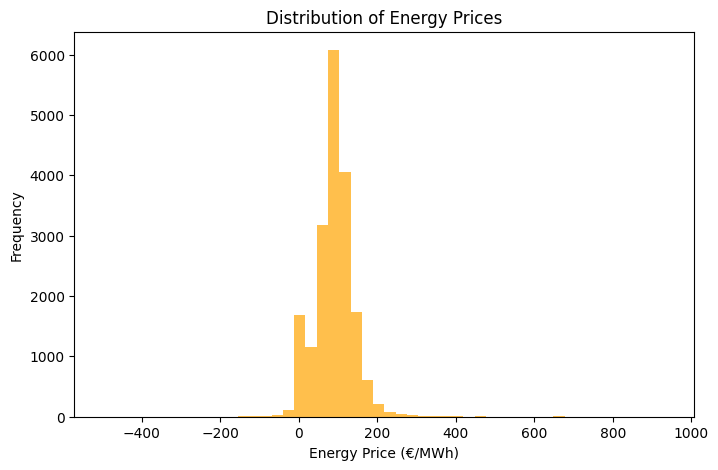

Percentage of Negative Prices: 4.11%


In [92]:
plt.figure(figsize=(8, 5))
plt.hist(df['energy_price'], bins=50, color='#FFA500', alpha=0.7)
plt.title('Distribution of Energy Prices')
plt.xlabel('Energy Price (€/MWh)')
plt.ylabel('Frequency')
plt.show()

# Calculate percentage of negative prices
negative_prices = (df['energy_price'] < 0).mean() * 100
print(f"Percentage of Negative Prices: {negative_prices:.2f}%")

### Correlations



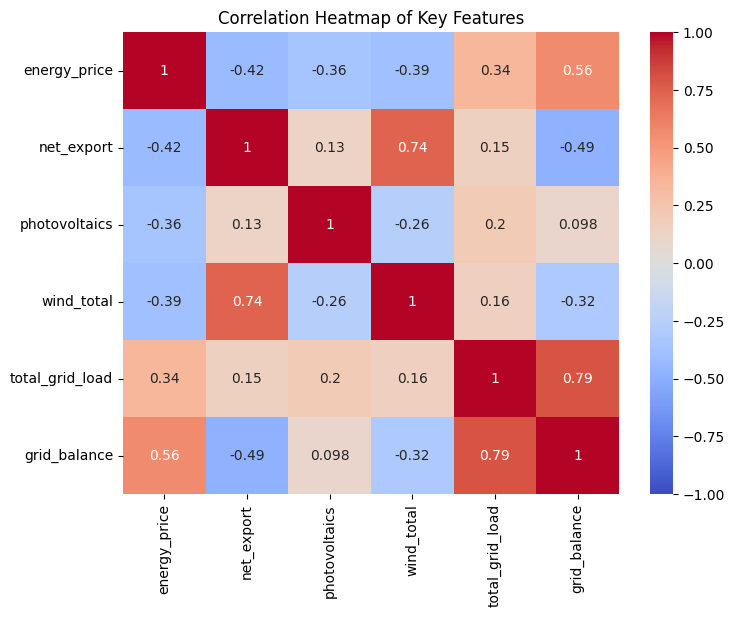

Correlation between Energy Price and Net Export: -0.42
Correlation between Energy Price and Photovoltaics: -0.36
Correlation between Energy Price and Wind Total: -0.39


In [78]:
import seaborn as sns

correlation_matrix = df[['energy_price', 'net_export', 'photovoltaics', 'wind_total', 'total_grid_load', 'grid_balance']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Key Features')
plt.show()

print(f"Correlation between Energy Price and Net Export: {correlation_matrix.loc['energy_price', 'net_export']:.2f}")
print(f"Correlation between Energy Price and Photovoltaics: {correlation_matrix.loc['energy_price', 'photovoltaics']:.2f}")
print(f"Correlation between Energy Price and Wind Total: {correlation_matrix.loc['energy_price', 'wind_total']:.2f}")

### Cross-Border Flow Impact

#### Net Export Impact

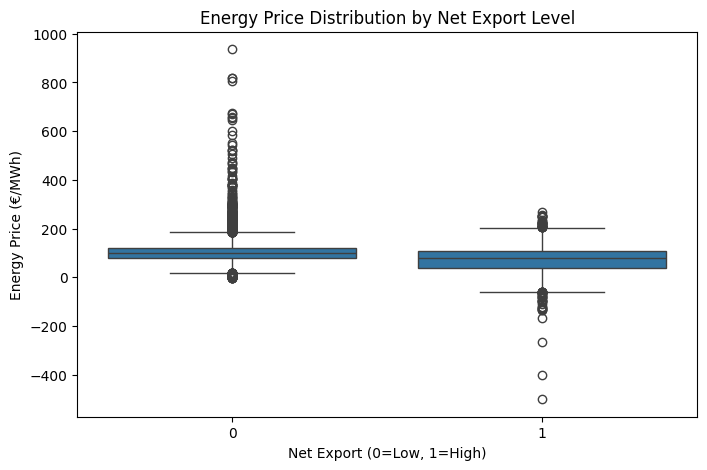

Average Price Difference (High - Low Net Export): -32.25 €/MWh


In [79]:
df['net_export_high'] = (df['net_export'] > df['net_export'].median()).astype(int)
plt.figure(figsize=(8, 5))
sns.boxplot(x='net_export_high', y='energy_price', data=df)
plt.title('Energy Price Distribution by Net Export Level')
plt.xlabel('Net Export (0=Low, 1=High)')
plt.ylabel('Energy Price (€/MWh)')
plt.show()

avg_price_high_export = df[df['net_export_high'] == 1]['energy_price'].mean()
avg_price_low_export = df[df['net_export_high'] == 0]['energy_price'].mean()
print(f"Average Price Difference (High - Low Net Export): {avg_price_high_export - avg_price_low_export:.2f} €/MWh")

### Renewable Generation Impact



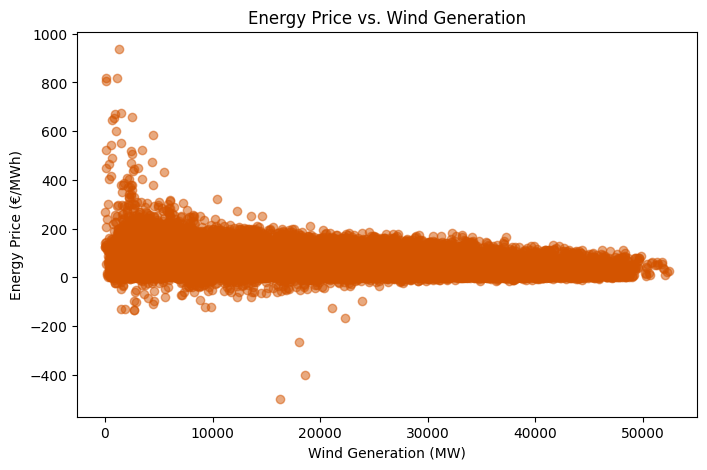

Average Price Difference (High - Low Wind): -32.41 €/MWh


'Prices drop with high wind generation—when wind turbines spin faster,\n prices fall by X €/MWh, as Germany’s grid gets a clean energy boost\n'

In [90]:
plt.figure(figsize=(8, 5))
plt.scatter(df['wind_total'], df['energy_price'], alpha=0.5, color='#d35400')
plt.title('Energy Price vs. Wind Generation')
plt.xlabel('Wind Generation (MW)')
plt.ylabel('Energy Price (€/MWh)')
plt.show()

# Calculate average price difference
df['wind_high'] = (df['wind_total'] > df['wind_total'].median()).astype(int)
avg_price_high_wind = df[df['wind_high'] == 1]['energy_price'].mean()
avg_price_low_wind = df[df['wind_high'] == 0]['energy_price'].mean()
print(f"Average Price Difference (High - Low Wind): {avg_price_high_wind - avg_price_low_wind:.2f} €/MWh")

"""Prices drop with high wind generation—when wind turbines spin faster,
 prices fall by X €/MWh, as Germany’s grid gets a clean energy boost
"""

### Demand Impact

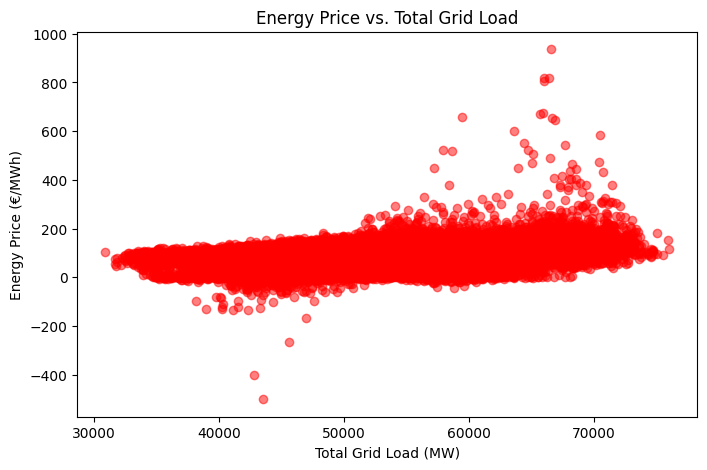

Average Price Difference (High - Low Load): 29.84 €/MWh


In [80]:
plt.figure(figsize=(8, 5))
plt.scatter(df['total_grid_load'], df['energy_price'], alpha=0.5, color='red')
plt.title('Energy Price vs. Total Grid Load')
plt.xlabel('Total Grid Load (MW)')
plt.ylabel('Energy Price (€/MWh)')
plt.show()

df['load_high'] = (df['total_grid_load'] > df['total_grid_load'].median()).astype(int)
avg_price_high_load = df[df['load_high'] == 1]['energy_price'].mean()
avg_price_low_load = df[df['load_high'] == 0]['energy_price'].mean()
print(f"Average Price Difference (High - Low Load): {avg_price_high_load - avg_price_low_load:.2f} €/MWh")

### Volatility Analysis

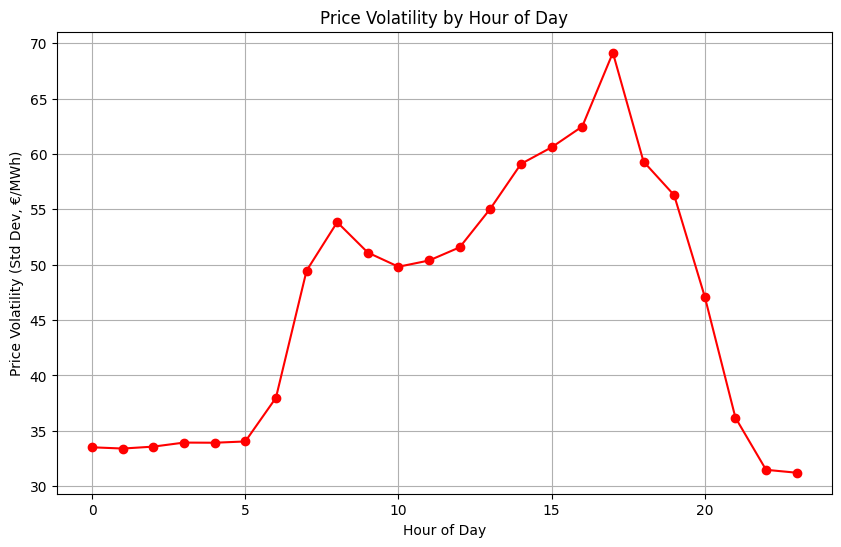

'\n\nPrices are a rollercoaster in the evening—volatility\npeaks at 18:00 as demand surges and solar power fades, \nwith prices swinging by X €/MWh.\n'

In [ ]:
hourly_price_std = df.groupby('hour_of_day')['energy_price'].std()
plt.figure(figsize=(10, 6))
plt.plot(hourly_price_std.index, hourly_price_std.values, marker='o', color='red')
plt.title('Price Volatility by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Price Volatility (Std Dev, €/MWh)')
plt.grid(True)
plt.show()

"""
Prices are a rollercoaster in the evening—volatility
peaks at 18:00 as demand surges and solar power fades, 
with prices swinging by X €/MWh.
"""

### Extreme Event Distribution



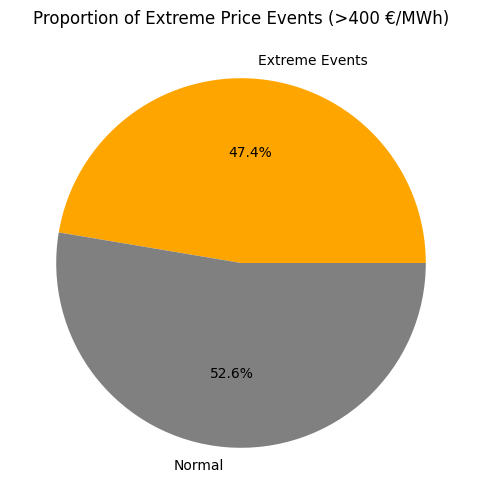

In [93]:
extreme_events = df['price_spike'].mean() * 100
plt.figure(figsize=(6, 6))
plt.pie([extreme_events, 100 - extreme_events], labels=['Extreme Events', 'Normal'], colors=['orange', 'grey'], autopct='%1.1f%%')
plt.title('Proportion of Extreme Price Events (>400 €/MWh)')
plt.show()